# 🌾 Crop Disease Detection — Multi-Model Inference Notebook
### Compare MobileNet V3 Large · ResNet-50 · EfficientNet-B3

**Upload any leaf image and instantly:**
- Run all 3 trained models
- See timing bars comparing inference speed
- View beautiful prediction graphs with confidence scores

---
*Milestone 6 | Crop Disease AI Assistant*

## Step 1 — Install Dependencies

In [2]:
# Install required libraries
!pip install -q torch torchvision timm Pillow matplotlib numpy tqdm
print("✅ Dependencies installed")

✅ Dependencies installed


## Step 2 — Load All 3 Models from Google Drive

In [20]:
import os
from google.colab import drive

drive.mount('/content/drive')

# ─── UPDATE THESE PATHS to match your Drive folder ───────────────────────────
DRIVE_FOLDER = '/content/drive/MyDrive/CropDisease/outputs'

DATA_ROOT = '/content/drive/MyDrive/DSAI Lab/DASI Lab Project/dataset/processed'  # to get class names
TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
TEST_DIR = os.path.join(DATA_ROOT, 'test')

MOBILENET_PATH    = os.path.join(DRIVE_FOLDER, 'mobilenet/best_mobilenet_full_model.pth')
RESNET_PATH       = os.path.join(DRIVE_FOLDER, 'resnet/best_resnet_full_model.pth')
EFFICIENTNET_PATH = os.path.join(DRIVE_FOLDER, 'efficientnet/best_efficientnet_full_model.pth')

# Check files exist
for name, path in [('MobileNet', MOBILENET_PATH), ('ResNet-50', RESNET_PATH), ('EfficientNet-B3', EFFICIENTNET_PATH)]:
    status = '✅ Found' if os.path.exists(path) else '❌ NOT FOUND — update path above'
    print(f'{name}: {status}')
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1e6
        print(f'   Size: {size_mb:.1f} MB')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MobileNet: ✅ Found
   Size: 17.1 MB
ResNet-50: ✅ Found
   Size: 94.5 MB
EfficientNet-B3: ✅ Found
   Size: 43.5 MB


## Step 3 — Define Model Architectures & Class Names

In [6]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets

# ─── 17 Class Names (must match training order from ImageFolder) ───────────

# Load class names from the training folder to ensure correct label order
train_ds = datasets.ImageFolder(TRAIN_DIR)
CLASS_NAMES = train_ds.classes
NUM_CLASSES = len(CLASS_NAMES)
print('Loaded class names:', NUM_CLASSES)


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE} ({"GPU" if torch.cuda.is_available() else "CPU"})')
print(f'Classes: {NUM_CLASSES}')

Loaded class names: 17
Device: cuda (GPU)
Classes: 17


In [11]:
def build_mobilenet_v3(num_classes=17, dropout=0.4704):
    model = models.mobilenet_v3_large(weights=None)
    in_f = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_f, 1280),
        nn.Hardswish(),
        nn.Dropout(p=dropout),
        nn.Linear(1280, num_classes)
    )
    return model

def build_resnet50(num_classes=17, dropout=0.1047):
    model = models.resnet50(weights=None)
    in_f = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_f, num_classes)
    )
    return model

def build_efficientnet_b3(num_classes=17, dropout=0.1755):
    model = models.efficientnet_b3(weights=None)
    in_f = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_f, num_classes)
    )
    return model

def load_model(build_fn, path, **kwargs):
    checkpoint = torch.load(path, map_location=DEVICE, weights_only=False)

    if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
        model = build_fn(**kwargs)
        model.load_state_dict(checkpoint['state_dict'])
    elif isinstance(checkpoint, dict) and not hasattr(checkpoint, 'forward'):
        model = build_fn(**kwargs)
        model.load_state_dict(checkpoint)
    else:
        model = checkpoint

    model.eval()
    return model.to(DEVICE)

print('Architecture definitions ready')

Architecture definitions ready


In [12]:
print('Loading models...')
models_dict = {}

try:
    models_dict['MobileNet V3 Large'] = load_model(build_mobilenet_v3, MOBILENET_PATH, num_classes=17, dropout=0.4704)
    print('✅ MobileNet V3 Large loaded')
except Exception as e:
    print(f'❌ MobileNet: {e}')

try:
    models_dict['ResNet-50'] = load_model(build_resnet50, RESNET_PATH, num_classes=17, dropout=0.10474185108130973)
    print('✅ ResNet-50 loaded')
except Exception as e:
    print(f'❌ ResNet-50: {e}')

try:
    models_dict['EfficientNet-B3'] = load_model(build_efficientnet_b3, EFFICIENTNET_PATH, num_classes=17, dropout=0.17550215585023377)
    print('✅ EfficientNet-B3 loaded')
except Exception as e:
    print(f'❌ EfficientNet-B3: {e}')

print(f'\nLoaded {len(models_dict)} / 3 models')

Loading models...
✅ MobileNet V3 Large loaded
✅ ResNet-50 loaded
✅ EfficientNet-B3 loaded

Loaded 3 / 3 models


## Step 4 — Upload a Leaf Image

Upload a leaf image (JPG or PNG):


Saving images (3).jpeg to images (3).jpeg


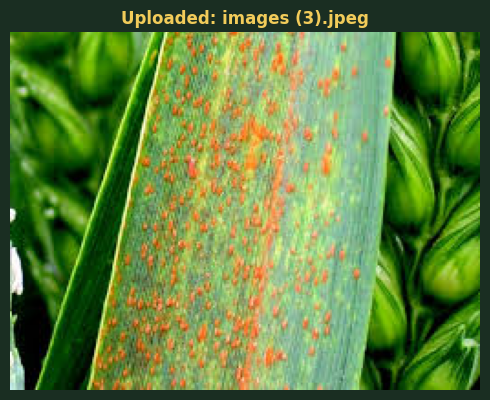

Image size: (257, 196)  |  Mode: RGB


In [13]:
from google.colab import files
from PIL import Image
import io

print('Upload a leaf image (JPG or PNG):')
uploaded = files.upload()

image_name = list(uploaded.keys())[0]
image_pil = Image.open(io.BytesIO(uploaded[image_name])).convert('RGB')

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.facecolor'] = '#1A2E22'
matplotlib.rcParams['text.color'] = 'white'
matplotlib.rcParams['axes.labelcolor'] = 'white'
matplotlib.rcParams['xtick.color'] = 'white'
matplotlib.rcParams['ytick.color'] = 'white'

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
fig.patch.set_facecolor('#1A2E22')
ax.imshow(image_pil)
ax.set_title(f'Uploaded: {image_name}', color='#F2CC5A', fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()
print(f'Image size: {image_pil.size}  |  Mode: {image_pil.mode}')

## Step 5 — Run All 3 Models with Timing

In [14]:
import torchvision.transforms as transforms
import time
import numpy as np

# ─── Inference transform (LANCZOS 224×224 — matches M2 preprocessing) ────────
TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224), interpolation=Image.LANCZOS),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def run_inference(model, image_pil, n_warmup=3, n_runs=10):
    """Run inference with warmup and timing. Returns (label, confidence, top5, avg_ms, all_probs)."""
    tensor = TRANSFORM(image_pil).unsqueeze(0).to(DEVICE)

    # Warmup (fills CUDA kernels / warms CPU cache)
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(tensor)

    # Timed runs
    times_ms = []
    for _ in range(n_runs):
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        with torch.no_grad():
            logits = model(tensor)
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        t1 = time.perf_counter()
        times_ms.append((t1 - t0) * 1000)

    probs = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    top5_idx = probs.argsort()[::-1][:5]
    label = CLASS_NAMES[probs.argmax()]
    confidence = probs.max()

    return {
        'label': label,
        'confidence': float(confidence),
        'top5': [(CLASS_NAMES[i], float(probs[i])) for i in top5_idx],
        'avg_ms': np.mean(times_ms),
        'std_ms': np.std(times_ms),
        'min_ms': np.min(times_ms),
        'all_probs': probs
    }

# ─── Run all models ───────────────────────────────────────────────────────────
results = {}
print(f'Running inference on: {image_name}')
print(f'Device: {DEVICE}  |  Warmup: 3 runs  |  Timed: 10 runs each')
print('-' * 60)

for model_name, model in models_dict.items():
    print(f'⏱  {model_name}...', end='', flush=True)
    res = run_inference(model, image_pil)
    results[model_name] = res
    print(f' {res["avg_ms"]:.1f}ms avg  →  {res["label"].replace("___"," | ")} ({res["confidence"]*100:.1f}%)')

print('\n✅ All models done!')

Running inference on: images (3).jpeg
Device: cuda  |  Warmup: 3 runs  |  Timed: 10 runs each
------------------------------------------------------------
⏱  MobileNet V3 Large... 6.8ms avg  →  Wheat | Brown_Rust (95.6%)
⏱  ResNet-50... 8.9ms avg  →  Wheat | Brown_Rust (100.0%)
⏱  EfficientNet-B3... 14.5ms avg  →  Sugarcane_Red Rot (100.0%)

✅ All models done!


## Step 6 — Visualise Results 📊

/tmp/ipykernel_3874/3699571574.py:127: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_conf.set_xticklabels([m.replace(' ', '\n') for m in model_names])


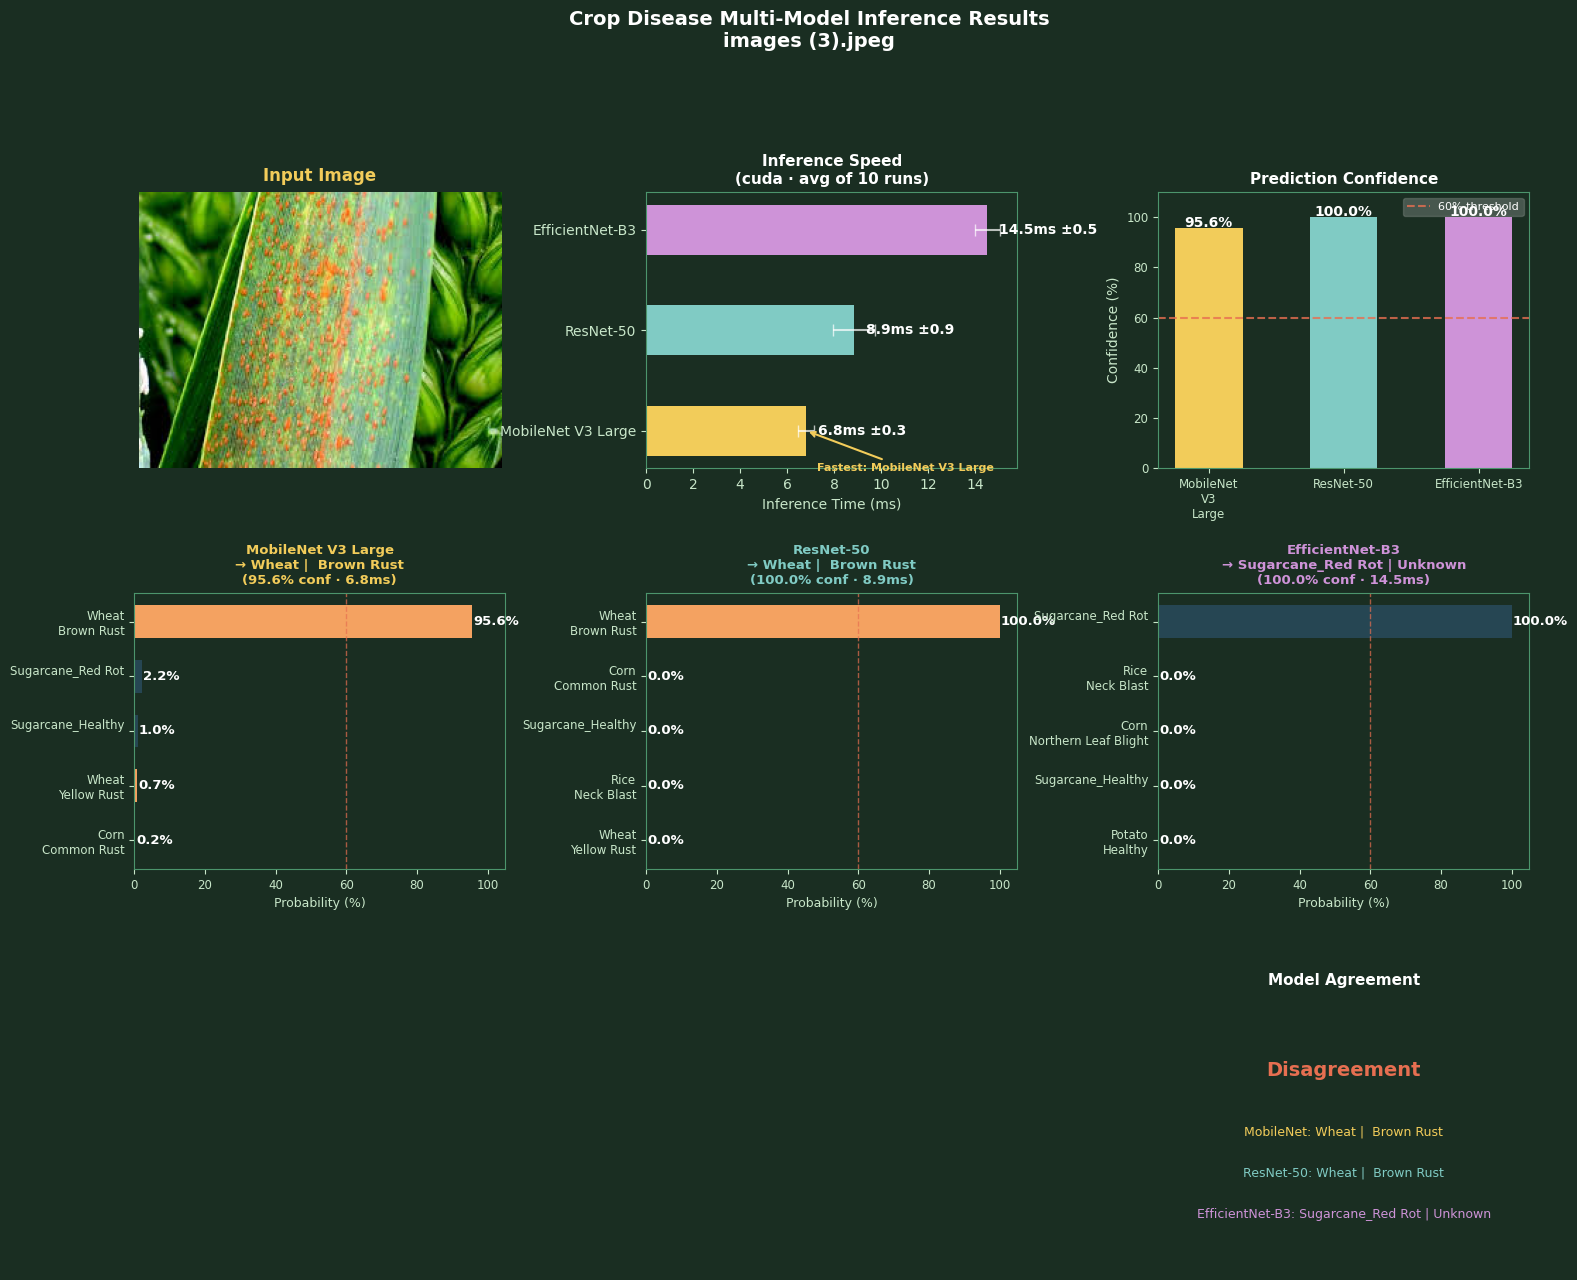


📊 Visualization saved as inference_results.png


In [28]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

# ─── Color palette ─────────────────────────────────────────────
BG      = '#1A2E22'
MG      = '#2C6E49'
LG      = '#4C956C'
YEL     = '#F2CC5A'
RED     = '#E76F51'
BLUE    = '#457B9D'
PURPLE  = '#7B3FA0'
WHITE   = '#FFFFFF'
MUTED   = '#C8E6C9'

MODEL_COLORS = {
    'MobileNet V3 Large': YEL,
    'ResNet-50':          '#80CBC4',
    'EfficientNet-B3':    '#CE93D8',
}

crop_colors_map = {
    'Corn':      '#E9C46A',
    'Potato':    '#E76F51',
    'Rice':      '#2A9D8F',
    'Wheat':     '#F4A261',
    'Sugarcane': '#264653',
}

def label_parts(label):
    parts = label.replace('__', '___').split('___')
    crop = parts[0] if len(parts) > 0 else 'Unknown'
    disease = parts[1].replace('_',' ') if len(parts) > 1 else 'Unknown'
    return crop, disease

fig = plt.figure(figsize=(18, 14), facecolor=BG)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

# ─── Top left: uploaded image ─────────────────────────────────
ax_img = fig.add_subplot(gs[0, 0])
ax_img.imshow(image_pil)
ax_img.set_title('Input Image', color=YEL, fontsize=12, fontweight='bold', pad=8)
ax_img.axis('off')

# ─── Top centre: timing bar chart ─────────────────────────────
ax_time = fig.add_subplot(gs[0, 1])
ax_time.set_facecolor(BG)

model_names = list(results.keys())
avg_times = [results[m]['avg_ms'] for m in model_names]
std_times = [results[m]['std_ms'] for m in model_names]
colors_t = [MODEL_COLORS[m] for m in model_names]

bars = ax_time.barh(
    model_names, avg_times,
    color=colors_t,
    edgecolor='none',
    height=0.5,
    xerr=std_times,
    error_kw={'ecolor':'white','capsize':4,'alpha':0.7}
)

for b, v, s in zip(bars, avg_times, std_times):
    ax_time.text(
        v + 0.5,
        b.get_y() + b.get_height()/2,
        f'{v:.1f}ms ±{s:.1f}',
        va='center',
        fontsize=10,
        color=WHITE,
        fontweight='bold'
    )

ax_time.set_xlabel('Inference Time (ms)', color=MUTED, fontsize=10)
ax_time.set_title(
    f'Inference Speed\n({DEVICE} · avg of 10 runs)',
    color=WHITE,
    fontsize=11,
    fontweight='bold'
)

ax_time.tick_params(colors=MUTED, labelsize=10)
for sp in ax_time.spines.values():
    sp.set_color(LG)

fastest = model_names[avg_times.index(min(avg_times))]
ax_time.annotate(
    f'Fastest: {fastest}',
    xy=(min(avg_times), 0),
    xytext=(max(avg_times)*0.5, -0.4),
    color=YEL,
    fontsize=8,
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=YEL, lw=1.5)
)

# ─── Top right: confidence comparison ─────────────────────────
ax_conf = fig.add_subplot(gs[0, 2])
ax_conf.set_facecolor(BG)

confs = [results[m]['confidence']*100 for m in model_names]
bars2 = ax_conf.bar(model_names, confs, color=colors_t, edgecolor='none', width=0.5)

for b, v in zip(bars2, confs):
    ax_conf.text(
        b.get_x() + b.get_width()/2,
        v + 0.5,
        f'{v:.1f}%',
        ha='center',
        fontsize=10,
        color=WHITE,
        fontweight='bold'
    )

ax_conf.set_ylim(0, 110)
ax_conf.axhline(60, color=RED, linestyle='--', linewidth=1.5, label='60% threshold', alpha=0.8)
ax_conf.set_ylabel('Confidence (%)', color=MUTED)

ax_conf.set_title('Prediction Confidence', color=WHITE, fontsize=11, fontweight='bold')
ax_conf.tick_params(colors=MUTED, labelsize=8.5)

for sp in ax_conf.spines.values():
    sp.set_color(LG)

ax_conf.legend(fontsize=8, labelcolor=WHITE, framealpha=0.2)
ax_conf.set_xticklabels([m.replace(' ', '\n') for m in model_names])

# ─── Per-model Top-5 bars ─────────────────────────────────────
for idx, model_name in enumerate(model_names):
    row = 1 + idx // 3
    col = idx % 3

    ax = fig.add_subplot(gs[row, col])
    ax.set_facecolor(BG)

    top5 = results[model_name]['top5']

    labels_t5 = [
        f'{l.split("___")[0]}\n{l.split("___")[1].replace("_"," ") if "___" in l else ""}'
        for l, _ in top5
    ]

    probs_t5 = [p * 100 for _, p in top5]

    crop_colors_t5 = [
        crop_colors_map.get(
            l.split('___')[0] if '___' in l else l.split('_')[0],
            LG
        )
        for l, _ in top5
    ]

    bars_t5 = ax.barh(
        labels_t5[::-1],
        probs_t5[::-1],
        color=crop_colors_t5[::-1],
        edgecolor='none',
        height=0.6
    )

    for b, v in zip(bars_t5, probs_t5[::-1]):
        ax.text(
            v + 0.3,
            b.get_y() + b.get_height()/2,
            f'{v:.1f}%',
            va='center',
            fontsize=9.5,
            color=WHITE,
            fontweight='bold'
        )

    crop, disease = label_parts(results[model_name]['label'])

    ax.set_title(
        f'{model_name}\n→ {crop} | {disease}\n'
        f'({results[model_name]["confidence"]*100:.1f}% conf · {results[model_name]["avg_ms"]:.1f}ms)',
        color=MODEL_COLORS[model_name],
        fontsize=9.5,
        fontweight='bold'
    )

    ax.tick_params(colors=MUTED, labelsize=8.5)

    for sp in ax.spines.values():
        sp.set_color(LG)

    ax.set_xlim(0, 105)
    ax.axvline(60, color=RED, linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlabel('Probability (%)', color=MUTED, fontsize=9)

# ─── Agreement panel ─────────────────────────────────────────
if len(model_names) > 0:
    ax_agree = fig.add_subplot(gs[2, 2])
    ax_agree.set_facecolor(BG)

    preds = [results[m]['label'] for m in model_names]
    crops_pred = [label_parts(p)[0] for p in preds]
    diseases_pred = [label_parts(p)[1] for p in preds]

    all_same = len(set(preds)) == 1
    same_crop = len(set(crops_pred)) == 1

    title_color = YEL if all_same else ('#80CBC4' if same_crop else RED)
    agreement = (
        'Full Agreement' if all_same
        else ('Crop Agreement' if same_crop else 'Disagreement')
    )

    ax_agree.text(
        0.5, 0.72, agreement,
        ha='center', va='center',
        fontsize=14,
        color=title_color,
        fontweight='bold',
        transform=ax_agree.transAxes
    )

    for i, m in enumerate(model_names):
        crop, dis = label_parts(results[m]['label'])
        ax_agree.text(
            0.5, 0.5 - i*0.15,
            f'{m.split()[0]}: {crop} | {dis}',
            ha='center',
            va='center',
            fontsize=9,
            color=MODEL_COLORS[m],
            transform=ax_agree.transAxes
        )

    ax_agree.set_title('Model Agreement', color=WHITE, fontsize=11, fontweight='bold')
    ax_agree.axis('off')

plt.suptitle(
    f'Crop Disease Multi-Model Inference Results\n{image_name}',
    color=WHITE,
    fontsize=14,
    fontweight='bold',
    y=1.01
)

plt.savefig('inference_results.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print('\n📊 Visualization saved as inference_results.png')

## Step 7 — Summary Table

In [17]:
print('\n' + '='*70)
print('  INFERENCE SUMMARY')
print('='*70)
print(f'  Image:  {image_name}')
print(f'  Device: {DEVICE}')
print()
print(f'  {"Model":<22} {"Prediction":<30} {"Confidence":>12} {"Avg ms":>8}')
print('-'*70)
for m, r in results.items():
    crop, dis = label_parts(r['label'])
    pred_str = f'{crop} | {dis}'
    conf_str = f'{r["confidence"]*100:.1f}%'
    time_str = f'{r["avg_ms"]:.1f}ms'
    flag = ' ★' if r['avg_ms'] == min(res['avg_ms'] for res in results.values()) else ''
    print(f'  {m:<22} {pred_str:<30} {conf_str:>12} {time_str:>8}{flag}')
print('='*70)

# Agreement check
preds = [r['label'] for r in results.values()]
if len(set(preds)) == 1:
    print(f'\n  ✅ All models AGREE: {label_parts(preds[0])[0]} | {label_parts(preds[0])[1]}')
    print(f'     High confidence prediction — reliable result')
elif len(set([label_parts(p)[0] for p in preds])) == 1:
    print(f'\n  🟡 Models agree on CROP ({label_parts(preds[0])[0]}) but differ on disease')
    print(f'     Consider consulting KVK for field confirmation')
else:
    print(f'\n  ❌ Models DISAGREE — recommend KVK consultation')

print()
print('  Top-5 predictions per model:')
for m, r in results.items():
    print(f'\n  {m}:')
    for i, (cls, prob) in enumerate(r['top5']):
        crop, dis = label_parts(cls)
        bar = '█' * int(prob * 30)
        print(f'    {i+1}. {crop:<12} {dis:<25} {prob*100:5.1f}% {bar}')


  INFERENCE SUMMARY
  Image:  images (3).jpeg
  Device: cuda

  Model                  Prediction                       Confidence   Avg ms
----------------------------------------------------------------------
  MobileNet V3 Large     Wheat |  Brown Rust                   95.6%    6.8ms ★
  ResNet-50              Wheat |  Brown Rust                  100.0%    8.9ms
  EfficientNet-B3        Sugarcane_Red Rot | Unknown          100.0%   14.5ms

  ❌ Models DISAGREE — recommend KVK consultation

  Top-5 predictions per model:

  MobileNet V3 Large:
    1. Wheat         Brown Rust                95.6% ████████████████████████████
    2. Sugarcane_Red Rot Unknown                     2.2% 
    3. Sugarcane_Healthy Unknown                     1.0% 
    4. Wheat         Yellow Rust                0.7% 
    5. Corn          Common Rust                0.2% 

  ResNet-50:
    1. Wheat         Brown Rust               100.0% █████████████████████████████
    2. Corn          Common Rust          

## 📝 Notes

**Inference transform:** Direct LANCZOS 224×224 resize — matches the M2 preprocessing pipeline exactly. Using the standard ImageNet convention (Resize(256)→CenterCrop(224)) would introduce a pixel distribution shift and reduce accuracy.

**Timing:** Results include `n_warmup=3` warmup runs (not timed) and `n_runs=10` timed runs averaged. GPU CUDA synchronisation is applied before/after each timed run to ensure accurate measurement.

**Confidence threshold:** 60% is the production threshold. Predictions below this trigger a cautious response and KVK referral in the deployed app.

**Model sources:** Download from the Google Drive artifacts folder linked in the README. Place at the paths defined in Step 2.

**Agreement colour codes:**  
- ✅ Green — all 3 models predict the same disease → high reliability  
- 🟡 Yellow — same crop, different disease → likely correct crop, uncertain disease  
- ❌ Red — models disagree → recommend professional field consultation

# Testing all models on test data

In [21]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

IMG_SIZE = 224  # change if your models used something else

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,   # <-- set this path
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Test samples: {len(test_dataset)}")

Test samples: 1277


In [23]:
!pip install tqdm

In [24]:
import torch
import time
from tqdm import tqdm

def evaluate_model(model, dataloader, device, model_name="Model"):
    model.eval()

    total = 0
    correct_top1 = 0
    correct_top5 = 0
    total_time = 0.0

    progress_bar = tqdm(
        dataloader,
        desc=f"{model_name}",
        leave=True
    )

    with torch.no_grad():
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            # ---- Accurate timing (GPU safe) ----
            if device.type == "cuda":
                torch.cuda.synchronize()

            start = time.perf_counter()
            outputs = model(images)

            if device.type == "cuda":
                torch.cuda.synchronize()

            end = time.perf_counter()

            total_time += (end - start)

            probs = torch.softmax(outputs, dim=1)

            # Top-1
            _, preds = torch.max(probs, 1)
            correct_top1 += (preds == labels).sum().item()

            # Top-5
            top5 = torch.topk(probs, 5, dim=1).indices
            correct_top5 += sum([
                labels[i].item() in top5[i].tolist()
                for i in range(labels.size(0))
            ])

            total += labels.size(0)

            # ---- Update progress bar ----
            progress_bar.set_postfix({
                "samples": total,
                "acc": f"{correct_top1/total:.3f}",
            })

    avg_time_per_sample = (total_time / total) * 1000

    return {
        "accuracy": correct_top1 / total,
        "top5_accuracy": correct_top5 / total,
        "avg_ms": avg_time_per_sample
    }

In [25]:
print("Running evaluation on test set...\n")

benchmark_results = {}

for name, model in models_dict.items():
    print(f"\n🔍 Evaluating {name}...\n")

    res = evaluate_model(model, test_loader, DEVICE, model_name=name)
    benchmark_results[name] = res

    print(
        f"\n{name} → "
        f"Acc: {res['accuracy']:.4f} | "
        f"Top5: {res['top5_accuracy']:.4f} | "
        f"Speed: {res['avg_ms']:.2f} ms/sample\n"
    )

print("All models evaluated.")

Running evaluation on test set...


🔍 Evaluating MobileNet V3 Large...



MobileNet V3 Large: 100%|██████████| 40/40 [06:54<00:00, 10.37s/it, samples=1277, acc=0.907]



MobileNet V3 Large → Acc: 0.9068 | Top5: 0.9992 | Speed: 0.93 ms/sample


🔍 Evaluating ResNet-50...



ResNet-50: 100%|██████████| 40/40 [00:06<00:00,  5.82it/s, samples=1277, acc=0.957]



ResNet-50 → Acc: 0.9569 | Top5: 0.9992 | Speed: 2.63 ms/sample


🔍 Evaluating EfficientNet-B3...



EfficientNet-B3: 100%|██████████| 40/40 [00:07<00:00,  5.36it/s, samples=1277, acc=0.655]


EfficientNet-B3 → Acc: 0.6547 | Top5: 0.8747 | Speed: 2.40 ms/sample

All models evaluated.
